# MIMIC ML Tutorial - Predicting In-Hospital Mortality

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

### Load Data

In [2]:
ADMISSIONS_PATH = "ADMISSIONS.csv.gz"
PATIENTS_PATH = "PATIENTS.csv.gz"
LABEVENTS_PATH = "LABEVENTS.csv.gz"
D_LABITEMS_PATH = "D_LABITEMS.csv.gz"

In [3]:
admissions = pd.read_csv(
    ADMISSIONS_PATH,
    compression="gzip",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ADMITTIME",
        "DISCHTIME",
        "DEATHTIME",
        "ADMISSION_TYPE",
        "INSURANCE",
        "LANGUAGE",
        "RELIGION",
        "MARITAL_STATUS",
        "ETHNICITY",
        "DIAGNOSIS",
        "HOSPITAL_EXPIRE_FLAG"
    ]
)

patients = pd.read_csv(
    PATIENTS_PATH,
    compression="gzip",
    usecols=[
        "SUBJECT_ID",
        "GENDER",
        "DOB"
    ]
)

d_labitems = pd.read_csv(
    D_LABITEMS_PATH,
    compression="gzip",
    usecols=[
        "ITEMID",
        "LABEL",
        "FLUID",
        "CATEGORY"
    ]
)

In [ ]:
# Convert date columns to datetime format
admissions["ADMITTIME"] = pd.to_datetime(admissions["ADMITTIME"])
admissions["DISCHTIME"] = pd.to_datetime(admissions["DISCHTIME"])
admissions["DEATHTIME"] = pd.to_datetime(admissions["DEATHTIME"])

patients["DOB"] = pd.to_datetime(patients["DOB"])

admissions.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG
0,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,BENZODIAZEPINE OVERDOSE,0
1,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaT,ELECTIVE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0
2,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaT,EMERGENCY,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,BRAIN MASS,0
3,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaT,EMERGENCY,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,INTERIOR MYOCARDIAL INFARCTION,0
4,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,ACUTE CORONARY SYNDROME,0


In [ ]:
# Merge patients with admissions to get patient demographics
df = admissions.merge(
    patients,
    on="SUBJECT_ID",
    how="left"
)

df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,GENDER,DOB
0,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,BENZODIAZEPINE OVERDOSE,0,F,2131-05-07
1,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaT,ELECTIVE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,M,2082-07-17
2,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaT,EMERGENCY,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,BRAIN MASS,0,M,2082-07-17
3,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaT,EMERGENCY,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,INTERIOR MYOCARDIAL INFARCTION,0,M,2100-05-31
4,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,ACUTE CORONARY SYNDROME,0,M,2101-11-21


### Feature Engineering

In [ ]:
# Calculate age
df["AGE"] = df["ADMITTIME"].dt.year - df["DOB"].dt.year

# Adjust age if the birthday had not occurred yet during the admission year
birthday_not_reached = (
    (df["ADMITTIME"].dt.month < df["DOB"].dt.month) |
    (
        (df["ADMITTIME"].dt.month == df["DOB"].dt.month) &
        (df["ADMITTIME"].dt.day < df["DOB"].dt.day)
    )
)

df.loc[birthday_not_reached, "AGE"] = df.loc[birthday_not_reached, "AGE"] - 1

# MIMIC-III masks ages above 89, so cap age at 90
df["AGE"] = df["AGE"].clip(lower=0, upper=90)

# Calculate length of stay in days
df["LOS_DAYS"] = (df["DISCHTIME"] - df["ADMITTIME"]).dt.total_seconds() / (60 * 60 * 24)

# Set target to mortality flag (1 if patient died during hospital stay, 0 otherwise)
df["TARGET"] = df["HOSPITAL_EXPIRE_FLAG"]

df[["SUBJECT_ID", "HADM_ID", "AGE", "GENDER", "LOS_DAYS", "TARGET"]].head()

,SUBJECT_ID,HADM_ID,AGE,GENDER,LOS_DAYS,TARGET
0,22,165315,64,F,1.144444,0
1,23,152223,71,M,5.496528,0
2,23,124321,75,M,6.768056,0
3,24,161859,39,M,2.856944,0
4,25,129635,58,M,3.534028,0


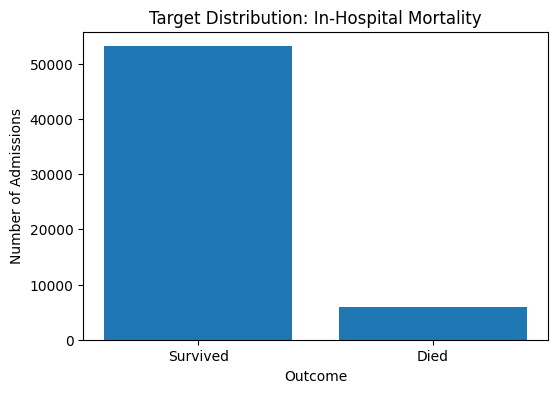

In [9]:
# View target distribution
target_counts = df["TARGET"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Survived", "Died"], target_counts.values)
plt.title("Target Distribution: In-Hospital Mortality")
plt.ylabel("Number of Admissions")
plt.xlabel("Outcome")
plt.show()

In [10]:
# Select common lab tests 
common_labs = [
    "HEMATOCRIT",
    "HEMOGLOBIN",
    "PLATELET COUNT",
    "WHITE BLOOD CELLS",
    "CREATININE",
    "UREA NITROGEN",
    "SODIUM",
    "POTASSIUM",
    "CHLORIDE",
    "BICARBONATE",
    "GLUCOSE",
    "ANION GAP"
]

# Normalize labels to uppercase
d_labitems["LABEL_UPPER"] = d_labitems["LABEL"].str.upper().str.strip()

selected_labitems = d_labitems[d_labitems["LABEL_UPPER"].isin(common_labs)]

selected_labitems[["ITEMID", "LABEL", "FLUID", "CATEGORY"]]

,ITEMID,LABEL,FLUID,CATEGORY
136,50809,Glucose,Blood,Blood Gas
138,50811,Hemoglobin,Blood,Blood Gas
160,50833,Potassium,Other Body Fluid,Blood Gas
195,50868,Anion Gap,Blood,Chemistry
209,50882,Bicarbonate,Blood,Chemistry
229,50902,Chloride,Blood,Chemistry
239,50912,Creatinine,Blood,Chemistry
258,50931,Glucose,Blood,Chemistry
298,50971,Potassium,Blood,Chemistry
310,50983,Sodium,Blood,Chemistry


In [12]:
selected_itemids = selected_labitems["ITEMID"].unique().tolist()

# Load lab events
labevents = pd.read_csv(
    LABEVENTS_PATH,
    compression="gzip",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ITEMID",
        "CHARTTIME",
        "VALUENUM"
    ]
)

# Keep only lab tests selected above
labevents = labevents[labevents["ITEMID"].isin(selected_itemids)]
labevents = labevents.dropna(subset=["VALUENUM"])

# Convert timestamp
labevents["CHARTTIME"] = pd.to_datetime(labevents["CHARTTIME"])

# Attach lab names to lab events
lab_lookup = selected_labitems[["ITEMID", "LABEL_UPPER"]].drop_duplicates()

labevents = labevents.merge(
    lab_lookup,
    on="ITEMID",
    how="left"
)

labevents.head()

,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUENUM,LABEL_UPPER
0,3,NaN,50868,2101-10-13 03:00:00,13.0,ANION GAP
1,3,NaN,50882,2101-10-13 03:00:00,23.0,BICARBONATE
2,3,NaN,50902,2101-10-13 03:00:00,109.0,CHLORIDE
3,3,NaN,50912,2101-10-13 03:00:00,1.7,CREATININE
4,3,NaN,50931,2101-10-13 03:00:00,137.0,GLUCOSE


In [13]:
# Only keep lab events that occurred within the first 24 hours of admission
lab_with_admit = labevents.merge(
    admissions[["HADM_ID", "ADMITTIME"]],
    on="HADM_ID",
    how="inner"
)

lab_with_admit["HOURS_FROM_ADMIT"] = (
    lab_with_admit["CHARTTIME"] - lab_with_admit["ADMITTIME"]
).dt.total_seconds() / 3600

first_24h_labs = lab_with_admit[
    (lab_with_admit["HOURS_FROM_ADMIT"] >= 0) &
    (lab_with_admit["HOURS_FROM_ADMIT"] <= 24)
]

first_24h_labs.head()

,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUENUM,LABEL_UPPER,ADMITTIME,HOURS_FROM_ADMIT
43,3,145834.0,51006,2101-10-20 19:26:00,41.0,UREA NITROGEN,2101-10-20 19:08:00,0.3
44,3,145834.0,51221,2101-10-20 19:26:00,24.9,HEMATOCRIT,2101-10-20 19:08:00,0.3
45,3,145834.0,51222,2101-10-20 19:26:00,7.8,HEMOGLOBIN,2101-10-20 19:08:00,0.3
46,3,145834.0,51265,2101-10-20 19:26:00,190.0,PLATELET COUNT,2101-10-20 19:08:00,0.3
47,3,145834.0,51301,2101-10-20 19:26:00,11.3,WHITE BLOOD CELLS,2101-10-20 19:08:00,0.3


In [14]:
# A patient may have the same lab measured multiple times in the first 24 hours
# Summarize each lab using mean, min, and max

lab_features = first_24h_labs.pivot_table(
    index="HADM_ID",
    columns="LABEL_UPPER",
    values="VALUENUM",
    aggfunc=["mean", "min", "max"]
)

# Flatten multi-index columns.
lab_features.columns = [
    f"{stat}_{lab}".replace(" ", "_")
    for stat, lab in lab_features.columns
]

lab_features = lab_features.reset_index()

lab_features.head()

,HADM_ID,mean_ANION_GAP,mean_BICARBONATE,mean_CHLORIDE,mean_CREATININE,mean_GLUCOSE,mean_HEMATOCRIT,mean_HEMOGLOBIN,mean_PLATELET_COUNT,mean_POTASSIUM,...,max_CHLORIDE,max_CREATININE,max_GLUCOSE,max_HEMATOCRIT,max_HEMOGLOBIN,max_PLATELET_COUNT,max_POTASSIUM,max_SODIUM,max_UREA_NITROGEN,max_WHITE_BLOOD_CELLS
0,100001.0,16.25,18.75,111.5,2.30,180.8,32.5,11.150,391.500000,4.075,...,114.0,2.4,300.0,32.8,11.3,407.0,4.2,144.0,42.0,11.2
1,100003.0,11.00,15.50,111.5,1.15,84.5,27.9,8.825,157.333333,5.000,...,112.0,1.2,113.0,31.8,10.4,162.0,5.0,133.0,49.0,14.2
2,100006.0,8.00,24.00,103.0,0.60,129.0,30.6,10.300,204.000000,3.700,...,103.0,0.6,129.0,30.6,10.3,204.0,3.7,131.0,16.0,13.6
3,100007.0,11.00,26.00,106.5,0.65,126.0,35.3,11.800,228.500000,4.400,...,107.0,0.7,137.0,37.1,12.3,259.0,4.7,140.0,14.0,12.3
4,100009.0,13.00,25.00,103.0,0.80,329.4,40.7,13.075,167.000000,4.200,...,103.0,0.8,1000.0,40.7,14.6,167.0,4.2,137.0,19.0,7.8


In [16]:
# Merge demographics/admission info with first-24-hour lab features for modeling
model_df = df.merge(
    lab_features,
    on="HADM_ID",
    how="left"
)

print(model_df.shape)
model_df.head()

(58976, 54)


,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,...,max_CHLORIDE,max_CREATININE,max_GLUCOSE,max_HEMATOCRIT,max_HEMOGLOBIN,max_PLATELET_COUNT,max_POTASSIUM,max_SODIUM,max_UREA_NITROGEN,max_WHITE_BLOOD_CELLS
0,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,...,105.0,0.6,108.0,NaN,NaN,NaN,3.4,142.0,9.0,NaN
1,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaT,ELECTIVE,Medicare,NaN,CATHOLIC,MARRIED,...,114.0,0.7,136.0,29.8,10.7,130.0,3.9,143.0,15.0,9.4
2,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaT,EMERGENCY,Medicare,ENGL,CATHOLIC,MARRIED,...,104.0,0.7,141.0,38.9,13.4,216.0,4.2,140.0,16.0,10.9
3,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaT,EMERGENCY,Private,NaN,PROTESTANT QUAKER,SINGLE,...,107.0,0.9,151.0,40.4,14.1,215.0,4.1,139.0,13.0,9.8
4,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaT,EMERGENCY,Private,NaN,UNOBTAINABLE,MARRIED,...,110.0,1.6,364.0,33.3,11.7,256.0,6.5,139.0,54.0,13.0


### Modeling

In [19]:
# Select features and target for modeling
target_col = "TARGET"

categorical_features = [
    "GENDER",
    "ADMISSION_TYPE",
    "INSURANCE",
    "LANGUAGE",
    "RELIGION",
    "MARITAL_STATUS",
    "ETHNICITY"
]

numeric_features = ["AGE"]

# Add all lab features.
lab_feature_cols = [
    col for col in model_df.columns
    if col.startswith("mean_") or col.startswith("min_") or col.startswith("max_")
]

numeric_features = numeric_features + lab_feature_cols

features = categorical_features + numeric_features

X = model_df[features]
y = model_df[target_col]

In [20]:
# Split data into train and test sets
# Set stratify=y so the train and test sets have similar mortality rates.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training rows: 47180
Testing rows: 11796

Training target distribution:
TARGET
0    0.900742
1    0.099258
Name: proportion, dtype: float64

Testing target distribution:
TARGET
0    0.900729
1    0.099271
Name: proportion, dtype: float64


In [21]:
# Fill missing values using median and standardize numeric values
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Fill missing categories with "Unknown" and one-hot encode categories
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [22]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained classification model.

    Parameters:
    model:
        A fitted sklearn pipeline or model.

    X_test:
        Test features.

    y_test:
        True target values.

    model_name:
        Name used for printed output and plots.
    """

    y_pred = model.predict(X_test)

    # Some models provide predicted probabilities.
    # AUC requires probabilities for the positive class.
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = np.nan

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc
    }

    print(f"================ {model_name} ================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("ROC AUC:", auc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Survived", "Died"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    # ROC curve
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve: {model_name}")
        plt.show()

    return metrics

### Model 1 - Logistic Regression

================ Logistic Regression ================
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     10625
           1       0.21      0.72      0.33      1171

    accuracy                           0.71     11796
   macro avg       0.58      0.71      0.57     11796
weighted avg       0.88      0.71      0.76     11796

ROC AUC: 0.7908107499874416


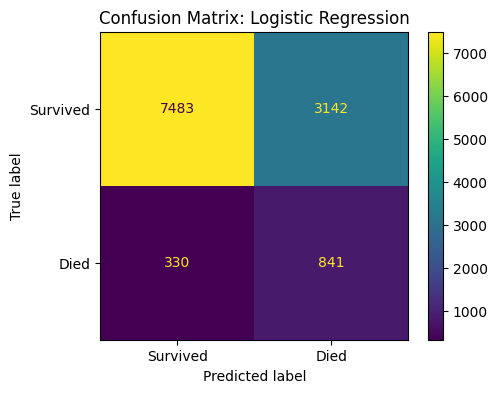

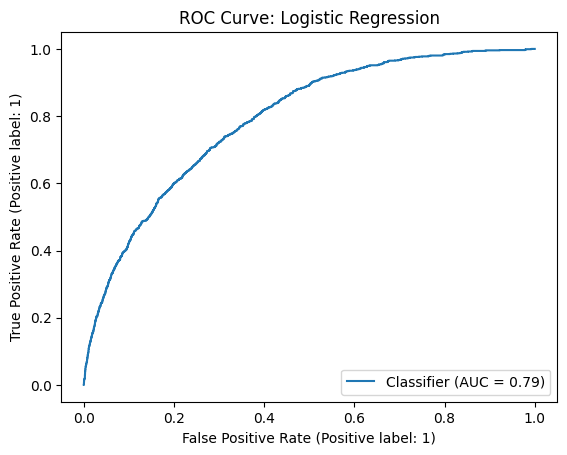

In [ ]:
# use class_weight="balanced" since death is usually the minority class
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

log_reg_metrics = evaluate_model(
    log_reg_model,
    X_test,
    y_test,
    "Logistic Regression"
)

### Model 2 - Random Forest

================ Random Forest ================
              precision    recall  f1-score   support

           0       0.95      0.78      0.86     10625
           1       0.25      0.66      0.36      1171

    accuracy                           0.77     11796
   macro avg       0.60      0.72      0.61     11796
weighted avg       0.88      0.77      0.81     11796

ROC AUC: 0.8163126136534887


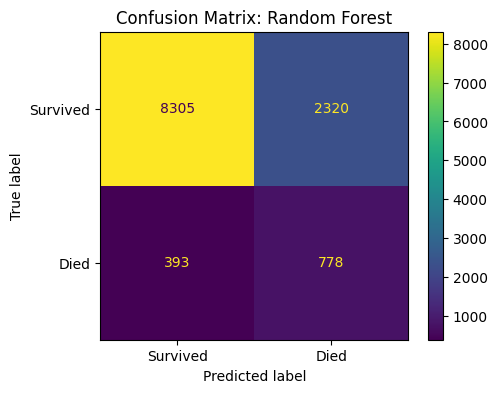

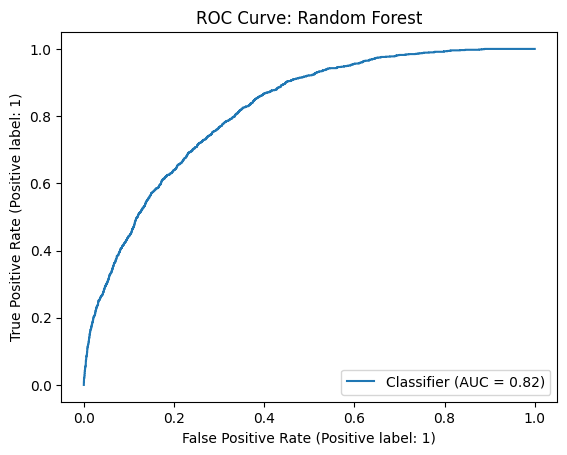

In [24]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

### Compare Models and RF Feature Importance

In [25]:
results = pd.DataFrame([
    log_reg_metrics,
    rf_metrics
])

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.705663,0.211147,0.718190,0.326348,0.790811
1,Random Forest,0.770007,0.251130,0.664389,0.364488,0.816313


In [27]:
def get_feature_names_from_pipeline(pipeline):
    """
    Extract transformed feature names from a sklearn pipeline
    containing a ColumnTransformer with numeric and categorical features.
    """

    preprocessor = pipeline.named_steps["preprocessor"]

    numeric_names = preprocessor.named_transformers_["num"].get_feature_names_out(numeric_features)

    categorical_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(
        categorical_features
    )

    all_feature_names = np.concatenate([numeric_names, categorical_names])

    return all_feature_names


rf_feature_names = get_feature_names_from_pipeline(rf_model)

rf_importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
0,AGE,0.064389
40,ADMISSION_TYPE_EMERGENCY,0.055025
23,min_UREA_NITROGEN,0.052188
11,mean_UREA_NITROGEN,0.047064
35,max_UREA_NITROGEN,0.038077
1,mean_ANION_GAP,0.034269
14,min_BICARBONATE,0.029568
2,mean_BICARBONATE,0.029044
25,max_ANION_GAP,0.028186
41,ADMISSION_TYPE_NEWBORN,0.026473


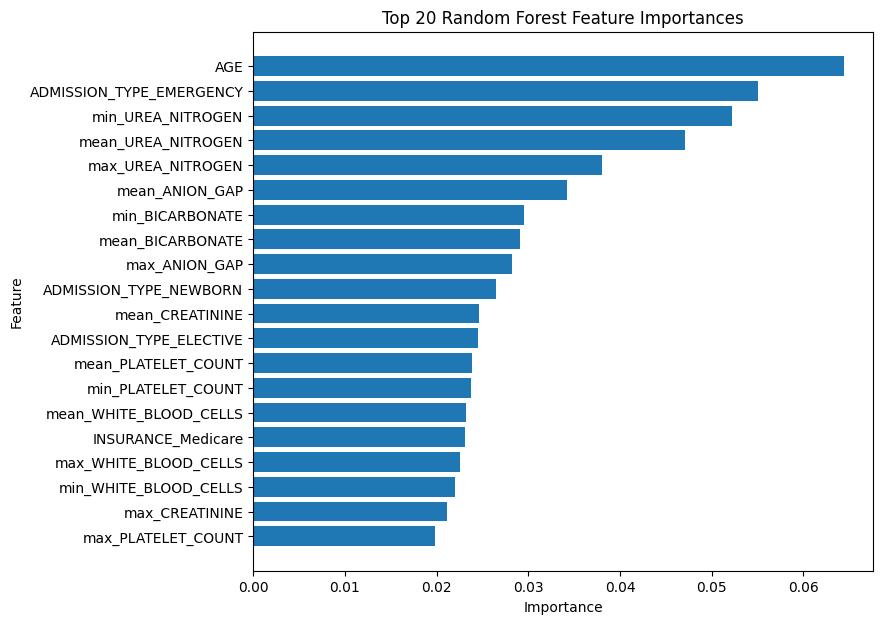

In [30]:
top_n = 20

top_features = importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(8, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [31]:
# log regression coefficients
log_reg_feature_names = get_feature_names_from_pipeline(log_reg_model)

log_reg_coefficients = log_reg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": log_reg_feature_names,
    "Coefficient": log_reg_coefficients
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

coef_df.head(20)

,Feature,Coefficient,AbsCoefficient
161,ETHNICITY_ASIAN - OTHER,1.674994,1.674994
105,LANGUAGE_JAPA,1.600011,1.600011
87,LANGUAGE_*URD,1.442632,1.442632
155,ETHNICITY_ASIAN - ASIAN INDIAN,-1.393487,1.393487
2,mean_BICARBONATE,-1.342315,1.342315
53,LANGUAGE_*AMH,1.297169,1.297169
23,min_UREA_NITROGEN,1.257178,1.257178
107,LANGUAGE_LAOT,1.252442,1.252442
174,ETHNICITY_HISPANIC/LATINO - GUATEMALAN,-1.216528,1.216528
145,MARITAL_STATUS_LIFE PARTNER,-1.191758,1.191758


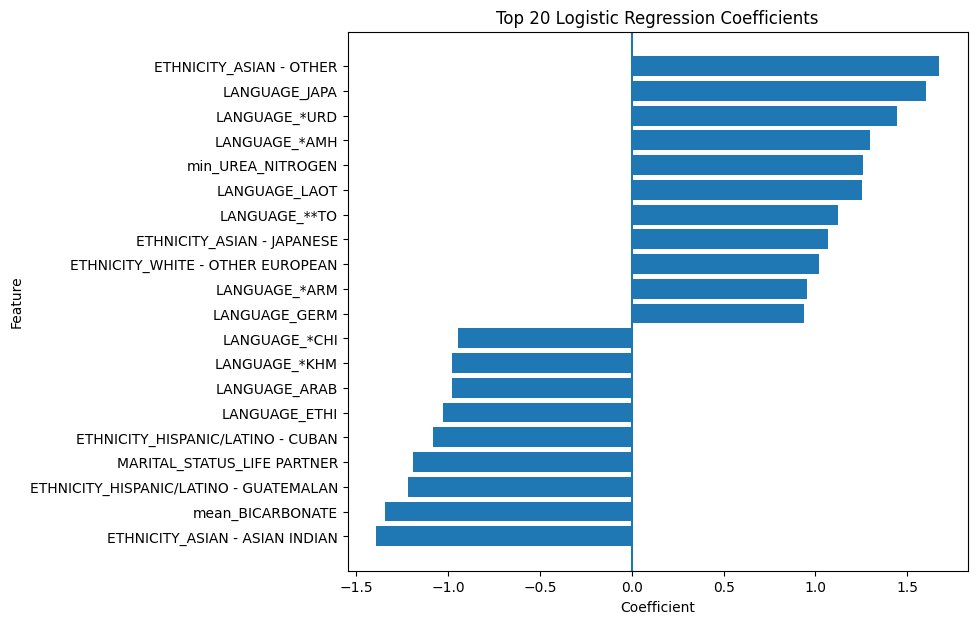

In [32]:
top_coef = coef_df.head(20).sort_values("Coefficient")

plt.figure(figsize=(8, 7))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.title("Top 20 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.axvline(0)
plt.show()